# Notebook 11 -- Modeling: Baseline

<div style="border-left: 4px solid #4680a7; padding: 10px 15px; margin: 10px 0; background: #4e6681;">

**Objective:** Establish baseline performance benchmarks using simple and standard classifiers on the integrated multimodal feature matrix. Implement the full training-evaluation pipeline (data loading, splitting, training, prediction, metric computation, threshold optimization, experiment logging).

**Answers:** *"What is the baseline predictive performance, and is the training infrastructure correct?"*

</div>

| Item | Detail |
|------|--------|
| **Dependencies** | `data/features/integrated/v1/train.parquet`, `data/features/integrated/v1/schema.json`, `configs/training/baseline.yaml` |
| **Artifacts** | `artifacts/models/baseline_v1/`, `artifacts/cv_folds_v1.json`, `reports/metrics/baseline_experiments.json`, `reports/metrics/baseline_comparison.json`, `reports/figures/modeling/` |
| **Scope** | Baseline benchmarking and structured evaluation only -- no hyperparameter tuning, no ensembling, no interpretability |
| **Runtime** | ~5-10 minutes |

---
## 1. Imports & Configuration

In [1]:
from __future__ import annotations

import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# -- Project imports -------------------------------------------------------
from adoption_accelerator import config
from adoption_accelerator.training.data_loader import (
    load_feature_schema,
    load_modeling_data,
    validate_modeling_inputs,
)
from adoption_accelerator.training.splitter import (
    create_cv_splitter,
    get_fold_indices,
    persist_fold_indices,
    validate_fold_balance,
)
from adoption_accelerator.training.trainer import cross_validate_model
from adoption_accelerator.training.evaluation import (
    compute_classification_metrics,
    compute_qwk,
    optimize_thresholds,
    apply_thresholds,
)
from adoption_accelerator.training.experiment_logger import (
    create_experiment_comparison,
    log_experiment,
    save_experiment_logs,
)
from adoption_accelerator.training.artifacts import (
    load_model_bundle,
    save_model_bundle,
)
from adoption_accelerator.training.visualization import (
    plot_confusion_matrix,
    plot_learning_curve,
    plot_model_comparison,
)

# -- Configuration ---------------------------------------------------------
CONFIG_PATH = config.PROJECT_ROOT / "configs" / "training" / "baseline.yaml"
with open(CONFIG_PATH, encoding="utf-8") as f:
    TRAIN_CFG = yaml.safe_load(f)

# -- Constants -------------------------------------------------------------
SEED = config.SEED
FEATURE_VERSION = TRAIN_CFG["feature_version"]
N_SPLITS = TRAIN_CFG["cv"]["n_splits"]
EXPECTED_TRAIN_ROWS = TRAIN_CFG["expected"]["train_rows"]
EXPECTED_FEATURES = TRAIN_CFG["expected"]["n_features"]

# -- Output paths ----------------------------------------------------------
FIGURES_DIR = config.REPORTS_FIGURES / "modeling"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

METRICS_DIR = config.REPORTS_METRICS
METRICS_DIR.mkdir(parents=True, exist_ok=True)

BUNDLE_PATH = config.ARTIFACTS_MODELS / "baseline_v1"
CV_FOLDS_PATH = config.ARTIFACTS_DIR / "cv_folds_v1.json"

np.random.seed(SEED)
t0 = time.time()

print(f"SEED              : {SEED}")
print(f"Feature version   : {FEATURE_VERSION}")
print(f"CV splits         : {N_SPLITS}")
print(f"Expected rows     : {EXPECTED_TRAIN_ROWS:,}")
print(f"Expected features : {EXPECTED_FEATURES}")
print(f"Figures dir       : {FIGURES_DIR}")
print(f"Model bundle dir  : {BUNDLE_PATH}")

SEED              : 42
Feature version   : v1
CV splits         : 5
Expected rows     : 14,993
Expected features : 940
Figures dir       : C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\reports\figures\modeling
Model bundle dir  : C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\artifacts\models\baseline_v1


---
## 2. Load Integrated Features

<div style="border-left: 4px solid #f39c12; padding: 10px 15px; margin: 10px 0; background: #5e5535;">

**Strategy:** Load the versioned integrated feature matrix produced by Notebook 10. The modeling phase consumes *only* the integrated Parquet -- it never accesses raw, cleaned, or modality-specific data directly.

</div>

In [2]:
# -- Load schema -----------------------------------------------------------
schema = load_feature_schema(FEATURE_VERSION)
print(f"Schema version : {schema['version']}")
print(f"Modality       : {schema['modality']}")
print(f"n_features     : {schema['n_features']}")
print(f"n_rows_train   : {schema['n_rows_train']:,}")
print(f"n_rows_test    : {schema['n_rows_test']:,}")

# -- Load train data -------------------------------------------------------
X, y = load_modeling_data(feature_version=FEATURE_VERSION, split="train")

print(f"\nFeature matrix X : {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"Target vector y  : {len(y):,} values")
print(f"Index name       : {X.index.name}")
print(f"Dtypes           : {dict(X.dtypes.value_counts())}")

Schema version : v1
Modality       : integrated
n_features     : 940
n_rows_train   : 14,993
n_rows_test    : 3,972

Feature matrix X : 14,993 rows x 940 columns
Target vector y  : 14,993 values
Index name       : PetID
Dtypes           : {dtype('float32'): np.int64(898), dtype('int8'): np.int64(17), dtype('int64'): np.int64(14), dtype('int32'): np.int64(5), dtype('float64'): np.int64(4), dtype('int16'): np.int64(2)}


---
## 3. Validation Gate G11-1 through G11-4 -- Data Integrity

In [3]:
# -- Run structured validation ---------------------------------------------
validation = validate_modeling_inputs(
    X, y,
    expected_rows=EXPECTED_TRAIN_ROWS,
    expected_features=EXPECTED_FEATURES,
)

for gate_id, result in validation["gates"].items():
    status = result["status"]
    severity = "CRITICAL" if result["critical"] else "WARNING"
    print(f"  {gate_id:<15s} [{status}] ({severity}) {result['message']}")

assert validation["passed"], "CRITICAL: Data validation failed -- halting."
print(f"\nAll data integrity gates PASSED.")

  G11-1a          [PASS] (CRITICAL) Row count: 14993 (expected 14993)
  G11-1b          [PASS] (CRITICAL) Feature count: 940 (expected 940)
  G11-3           [PASS] (CRITICAL) 'AdoptionSpeed' absent from feature matrix
  G11-4a          [PASS] (CRITICAL) NaN count: 0
  G11-4b          [PASS] (CRITICAL) Inf count: 0
  PetID-unique    [PASS] (CRITICAL) Duplicate PetIDs: 0
  G11-2           [PASS] (CRITICAL) Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  shape-align     [PASS] (CRITICAL) X rows (14993) == y length (14993)

All data integrity gates PASSED.


---
## 4. Target Distribution Analysis

In [4]:
# -- Target distribution ---------------------------------------------------
class_labels = TRAIN_CFG["target"]["class_labels"]
class_counts = y.value_counts().sort_index()
class_proportions = y.value_counts(normalize=True).sort_index()

dist_df = pd.DataFrame({
    "Class": [f"{k} - {class_labels[k]}" for k in sorted(class_labels.keys())],
    "Count": class_counts.values,
    "Proportion": class_proportions.values,
})
dist_df["Proportion"] = dist_df["Proportion"].map("{:.2%}".format)

imbalance_ratio = int(class_counts.max()) / int(class_counts.min())

print("AdoptionSpeed distribution:")
print(dist_df.to_string(index=False))
print(f"\nImbalance ratio (majority / minority): {imbalance_ratio:.2f}")
print(f"Majority class: {class_counts.idxmax()} ({class_labels[class_counts.idxmax()]})")
print(f"Minority class: {class_counts.idxmin()} ({class_labels[class_counts.idxmin()]})")

AdoptionSpeed distribution:
         Class  Count Proportion
  0 - Same day    410      2.73%
  1 - 1-7 days   3090     20.61%
 2 - 8-30 days   4037     26.93%
3 - 31-90 days   3259     21.74%
 4 - 100+ days   4197     27.99%

Imbalance ratio (majority / minority): 10.24
Majority class: 4 (100+ days)
Minority class: 0 (Same day)


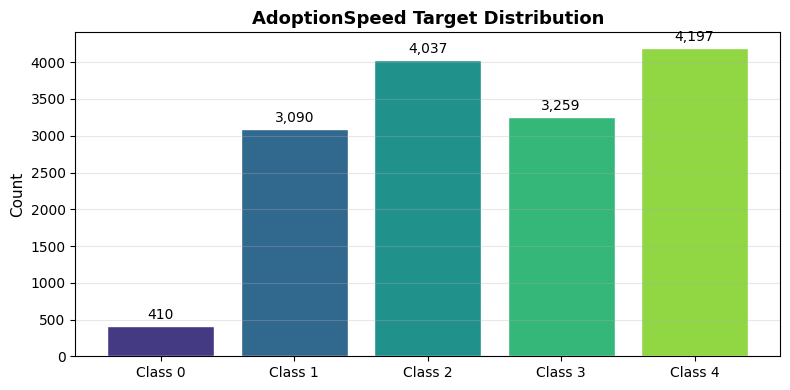

In [5]:
# -- Target distribution bar chart -----------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette("viridis", n_colors=5)
bars = ax.bar(
    [f"Class {k}" for k in class_counts.index],
    class_counts.values,
    color=colors,
    edgecolor="white",
)
for bar, cnt in zip(bars, class_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{cnt:,}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_ylabel("Count", fontsize=11)
ax.set_title("AdoptionSpeed Target Distribution", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Cross-Validation Strategy

<div style="border-left: 4px solid #f39c12; padding: 10px 15px; margin: 10px 0; background: #5e5535;">

**Strategy:** Stratified 5-fold CV with `random_state=42`. Stratification preserves the target class distribution within each fold. Fold indices are persisted to `artifacts/cv_folds_v1.json` for reuse by Notebook 12 (tuning), ensuring identical splits across all experiments.

</div>

In [6]:
# -- Create CV splitter and fold indices -----------------------------------
splitter = create_cv_splitter(n_splits=N_SPLITS, seed=SEED)
folds = get_fold_indices(X, y, splitter)

print(f"Splitter        : StratifiedKFold(n_splits={N_SPLITS}, shuffle=True, random_state={SEED})")
print(f"Number of folds : {len(folds)}")
for i, (train_idx, val_idx) in enumerate(folds):
    print(f"  Fold {i}: train={len(train_idx):,}  val={len(val_idx):,}")

Splitter        : StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Number of folds : 5
  Fold 0: train=11,994  val=2,999
  Fold 1: train=11,994  val=2,999
  Fold 2: train=11,994  val=2,999
  Fold 3: train=11,995  val=2,998
  Fold 4: train=11,995  val=2,998


In [7]:
# -- Validation Gate G11-5: Fold balance ------------------------------------
balance = validate_fold_balance(y, folds, tolerance=0.02)

for detail in balance["details"]:
    status = "PASS" if detail["within_tolerance"] else "FAIL"
    print(f"  Fold {detail['fold']}: max proportion diff = {detail['max_proportion_diff']:.4f} [{status}]")

assert balance["passed"], "G11-5 FAIL: Fold class proportions exceed 2% tolerance."
print(f"\nG11-5 PASS: All folds within {balance['tolerance']:.0%} tolerance of overall distribution.")

  Fold 0: max proportion diff = 0.0002 [PASS]
  Fold 1: max proportion diff = 0.0003 [PASS]
  Fold 2: max proportion diff = 0.0002 [PASS]
  Fold 3: max proportion diff = 0.0001 [PASS]
  Fold 4: max proportion diff = 0.0001 [PASS]

G11-5 PASS: All folds within 2% tolerance of overall distribution.


In [8]:
# -- Persist fold indices for Notebook 12 ----------------------------------
persist_fold_indices(folds, CV_FOLDS_PATH)
print(f"Fold indices saved to: {CV_FOLDS_PATH}")

# -- Validation Gate G11-12: Reproducibility check -------------------------
splitter_check = create_cv_splitter(n_splits=N_SPLITS, seed=SEED)
folds_check = get_fold_indices(X, y, splitter_check)
for i, ((t1, v1), (t2, v2)) in enumerate(zip(folds, folds_check)):
    assert np.array_equal(t1, t2), f"G11-12 FAIL: Fold {i} train indices differ"
    assert np.array_equal(v1, v2), f"G11-12 FAIL: Fold {i} val indices differ"
print("G11-12 PASS: Fold indices are reproducible with the same seed.")

Fold indices saved to: C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\artifacts\cv_folds_v1.json
G11-12 PASS: Fold indices are reproducible with the same seed.


---
## 6. Define Baseline Models

<div style="border-left: 4px solid #f39c12; padding: 10px 15px; margin: 10px 0; background: #5e5535;">

**Strategy:** Five baselines spanning from trivial (dummy) to default gradient-boosted trees. No hyperparameter tuning -- all models use out-of-the-box or minimal configurations. The goal is to establish the performance floor and verify the training infrastructure.

</div>

In [10]:
# -- Baseline model definitions --------------------------------------------
baseline_models = {
    "DummyMostFrequent": DummyClassifier(strategy="most_frequent"),
    "DummyStratified": DummyClassifier(strategy="stratified", random_state=SEED),
    "LogisticRegression": LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=SEED,
        C=1.0,
    ),
    "DecisionTree": DecisionTreeClassifier(random_state=SEED),
    "LightGBM_Default": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
    ),
}

print(f"Baseline models ({len(baseline_models)}):")
for name, model in baseline_models.items():
    params = {k: v for k, v in model.get_params().items() if v is not None}
    print(f"  {name:<25s} -> {type(model).__name__}")

Baseline models (5):
  DummyMostFrequent         -> DummyClassifier
  DummyStratified           -> DummyClassifier
  LogisticRegression        -> LogisticRegression
  DecisionTree              -> DecisionTreeClassifier
  LightGBM_Default          -> LGBMClassifier


---
## 7. Cross-Validation Training Loop

In [11]:
# -- Run cross-validation for all baselines --------------------------------
cv_results: dict[str, object] = {}

for name, model in baseline_models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")

    result = cross_validate_model(
        model=model,
        X=X,
        y=y,
        splitter=create_cv_splitter(n_splits=N_SPLITS, seed=SEED),
        threshold_optimize=True,
        model_name=name,
    )
    cv_results[name] = result

    agg = result.aggregated
    print(f"  Mean QWK (argmax)    : {agg['mean_qwk_argmax']:.4f} +/- {agg['std_qwk_argmax']:.4f}")
    print(f"  Mean QWK (threshold) : {agg['mean_qwk_threshold']:.4f} +/- {agg['std_qwk_threshold']:.4f}")
    print(f"  Mean Accuracy        : {agg['mean_accuracy']:.4f}")
    print(f"  Mean Macro-F1        : {agg['mean_macro_f1']:.4f}")
    print(f"  Training time        : {agg['training_time_seconds']:.1f}s")

# -- Validation Gate G11-6 -------------------------------------------------
assert len(cv_results) == len(baseline_models), (
    f"G11-6 FAIL: Only {len(cv_results)}/{len(baseline_models)} models completed CV."
)
print(f"\nG11-6 PASS: All {len(baseline_models)} baseline models completed cross-validation.")


Training: DummyMostFrequent
  Mean QWK (argmax)    : 0.0000 +/- 0.0000
  Mean QWK (threshold) : 0.0000 +/- 0.0000
  Mean Accuracy        : 0.2799
  Mean Macro-F1        : 0.0875
  Training time        : 0.5s

Training: DummyStratified
  Mean QWK (argmax)    : -0.0015 +/- 0.0076
  Mean QWK (threshold) : -0.0015 +/- 0.0076
  Mean Accuracy        : 0.2467
  Mean Macro-F1        : 0.2026
  Training time        : 0.5s

Training: LogisticRegression
  Mean QWK (argmax)    : 0.1644 +/- 0.0162
  Mean QWK (threshold) : 0.1867 +/- 0.0239
  Mean Accuracy        : 0.3560
  Mean Macro-F1        : 0.2428
  Training time        : 31.1s

Training: DecisionTree
  Mean QWK (argmax)    : 0.1738 +/- 0.0181
  Mean QWK (threshold) : 0.1738 +/- 0.0181
  Mean Accuracy        : 0.3278
  Mean Macro-F1        : 0.2752
  Training time        : 41.8s

Training: LightGBM_Default
  Mean QWK (argmax)    : 0.4015 +/- 0.0079
  Mean QWK (threshold) : 0.4488 +/- 0.0258
  Mean Accuracy        : 0.4407
  Mean Macro-F1     

---
## 8. Threshold Optimization Analysis

In [12]:
# -- Threshold optimization summary ----------------------------------------
print("Threshold Optimization: Argmax vs. Optimized QWK\n")
print(f"{'Model':<25s} {'QWK(argmax)':>12s} {'QWK(thresh)':>12s} {'Delta':>8s}")
print("-" * 60)

for name, result in cv_results.items():
    agg = result.aggregated
    argmax = agg["mean_qwk_argmax"]
    thresh = agg["mean_qwk_threshold"]
    delta = thresh - argmax
    print(f"{name:<25s} {argmax:>12.4f} {thresh:>12.4f} {delta:>+8.4f}")

# -- Validation Gate G11-9 (warning) ---------------------------------------
for name, result in cv_results.items():
    agg = result.aggregated
    if agg["mean_qwk_threshold"] < agg["mean_qwk_argmax"] - 1e-4:
        print(f"\nG11-9 WARNING: {name} -- threshold optimization DEGRADED QWK.")
    else:
        print(f"G11-9 PASS: {name} -- threshold QWK >= argmax QWK.")

Threshold Optimization: Argmax vs. Optimized QWK

Model                      QWK(argmax)  QWK(thresh)    Delta
------------------------------------------------------------
DummyMostFrequent               0.0000       0.0000  +0.0000
DummyStratified                -0.0015      -0.0015  +0.0000
LogisticRegression              0.1644       0.1867  +0.0223
DecisionTree                    0.1738       0.1738  +0.0000
LightGBM_Default                0.4015       0.4488  +0.0473
G11-9 PASS: DummyMostFrequent -- threshold QWK >= argmax QWK.
G11-9 PASS: DummyStratified -- threshold QWK >= argmax QWK.
G11-9 PASS: LogisticRegression -- threshold QWK >= argmax QWK.
G11-9 PASS: DecisionTree -- threshold QWK >= argmax QWK.
G11-9 PASS: LightGBM_Default -- threshold QWK >= argmax QWK.


---
## 9. Baseline Comparison Table

In [13]:
# -- Build comparison table ------------------------------------------------
comparison_rows = []
for name, result in cv_results.items():
    agg = result.aggregated
    comparison_rows.append({
        "model_name": name,
        "mean_qwk_argmax": round(agg["mean_qwk_argmax"], 4),
        "std_qwk_argmax": round(agg["std_qwk_argmax"], 4),
        "mean_qwk_threshold": round(agg["mean_qwk_threshold"], 4),
        "std_qwk_threshold": round(agg["std_qwk_threshold"], 4),
        "mean_accuracy": round(agg["mean_accuracy"], 4),
        "mean_macro_f1": round(agg["mean_macro_f1"], 4),
        "mean_weighted_f1": round(agg["mean_weighted_f1"], 4),
        "training_time_s": round(agg["training_time_seconds"], 1),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    "mean_qwk_threshold", ascending=False
).reset_index(drop=True)

comparison_df.index = comparison_df.index + 1
comparison_df.index.name = "Rank"
comparison_df

,model_name,mean_qwk_argmax,std_qwk_argmax,mean_qwk_threshold,std_qwk_threshold,mean_accuracy,mean_macro_f1,mean_weighted_f1,training_time_s
Rank,,,,,,,,,
1,LightGBM_Default,0.4015,0.0079,0.4488,0.0258,0.4407,0.3515,0.4238,24.5
2,LogisticRegression,0.1644,0.0162,0.1867,0.0239,0.3560,0.2428,0.3106,31.1
3,DecisionTree,0.1738,0.0181,0.1738,0.0181,0.3278,0.2752,0.3277,41.8
4,DummyMostFrequent,0.0000,0.0000,0.0000,0.0000,0.2799,0.0875,0.1224,0.5
5,DummyStratified,-0.0015,0.0076,-0.0015,0.0076,0.2467,0.2026,0.2461,0.5


In [14]:
# -- Validation Gate G11-7 -------------------------------------------------
best_model_name = comparison_df.iloc[0]["model_name"]
best_qwk = comparison_df.iloc[0]["mean_qwk_threshold"]
dummy_qwk = cv_results["DummyMostFrequent"].aggregated["mean_qwk_threshold"]

assert best_qwk > dummy_qwk, (
    f"G11-7 FAIL: Best baseline QWK ({best_qwk:.4f}) does not beat "
    f"DummyMostFrequent ({dummy_qwk:.4f})."
)
print(f"G11-7 PASS: Best baseline ({best_model_name}, QWK={best_qwk:.4f}) > DummyMostFrequent ({dummy_qwk:.4f}).")

# -- Validation Gate G11-8 (warning) ---------------------------------------
if best_qwk > 0.20:
    print(f"G11-8 PASS: Best baseline QWK ({best_qwk:.4f}) > 0.20 sanity threshold.")
else:
    print(f"G11-8 WARNING: Best baseline QWK ({best_qwk:.4f}) <= 0.20 -- non-degenerate learning not confirmed.")

G11-7 PASS: Best baseline (LightGBM_Default, QWK=0.4488) > DummyMostFrequent (0.0000).
G11-8 PASS: Best baseline QWK (0.4488) > 0.20 sanity threshold.


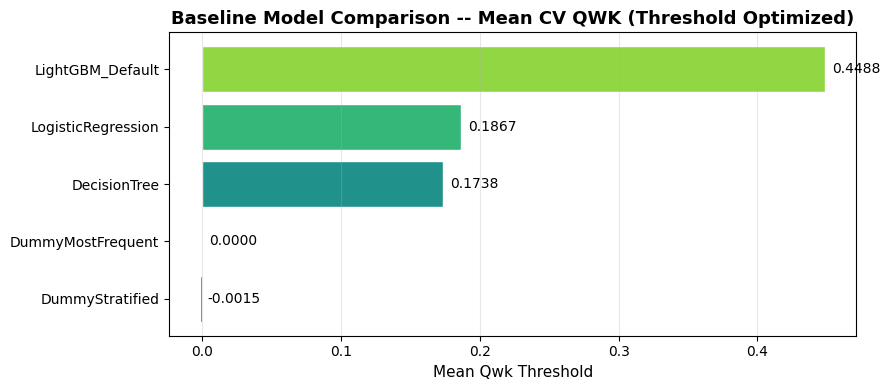

In [15]:
# -- Model comparison bar chart --------------------------------------------
fig = plot_model_comparison(
    comparison_df.reset_index(drop=True),
    metric_col="mean_qwk_threshold",
    title="Baseline Model Comparison -- Mean CV QWK (Threshold Optimized)",
    save_path=FIGURES_DIR / "baseline_comparison.png",
)
plt.show()

---
## 10. Per-Class Analysis (Best Baseline)

In [16]:
# -- Per-class metrics for the best baseline --------------------------------
best_result = cv_results[best_model_name]

# Compute metrics from OOF predictions
oof_true = best_result.oof_true
oof_preds = best_result.oof_predictions
oof_metrics = compute_classification_metrics(oof_true, oof_preds)

per_class_df = pd.DataFrame({
    "Class": [f"{i} - {class_labels[i]}" for i in range(5)],
    "Precision": [round(v, 4) for v in oof_metrics["per_class_precision"]],
    "Recall": [round(v, 4) for v in oof_metrics["per_class_recall"]],
    "F1": [round(v, 4) for v in oof_metrics["per_class_f1"]],
    "Support": class_counts.values,
})

print(f"Per-class metrics for best baseline: {best_model_name}")
print(f"OOF QWK: {oof_metrics['qwk']:.4f} | Accuracy: {oof_metrics['accuracy']:.4f} | Macro-F1: {oof_metrics['macro_f1']:.4f}\n")
print(per_class_df.to_string(index=False))

# Identify hardest class
hardest_class = int(np.argmin(oof_metrics["per_class_f1"]))
print(f"\nHardest class to predict: {hardest_class} ({class_labels[hardest_class]}) -- F1={oof_metrics['per_class_f1'][hardest_class]:.4f}")

Per-class metrics for best baseline: LightGBM_Default
OOF QWK: 0.4016 | Accuracy: 0.4407 | Macro-F1: 0.3517

         Class  Precision  Recall     F1  Support
  0 - Same day     0.7368  0.0341 0.0653      410
  1 - 1-7 days     0.4044  0.3573 0.3794     3090
 2 - 8-30 days     0.3594  0.4018 0.3794     4037
3 - 31-90 days     0.3902  0.2660 0.3164     3259
 4 - 100+ days     0.5446  0.7148 0.6182     4197

Hardest class to predict: 0 (Same day) -- F1=0.0653


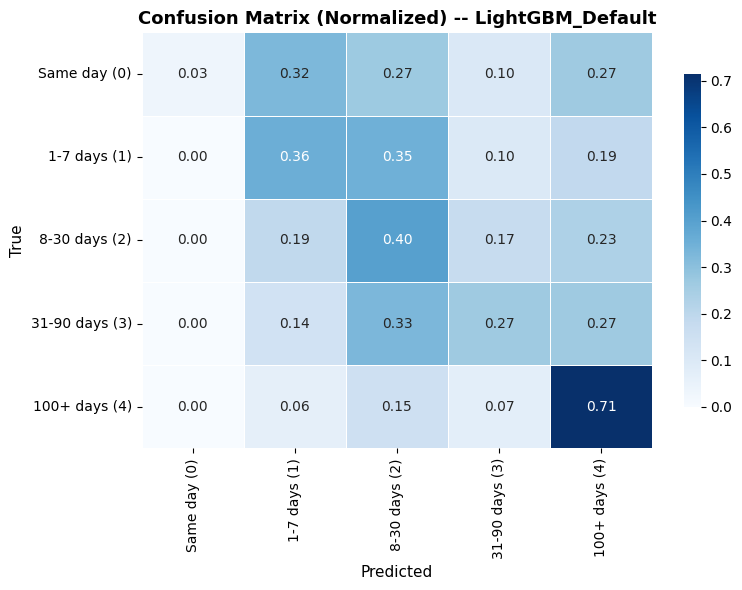

In [17]:
# -- Normalized confusion matrix (best baseline) ---------------------------
fig = plot_confusion_matrix(
    oof_true,
    oof_preds,
    normalize=True,
    title=f"Confusion Matrix (Normalized) -- {best_model_name}",
    save_path=FIGURES_DIR / "baseline_confusion_matrix_normalized.png",
)
plt.show()

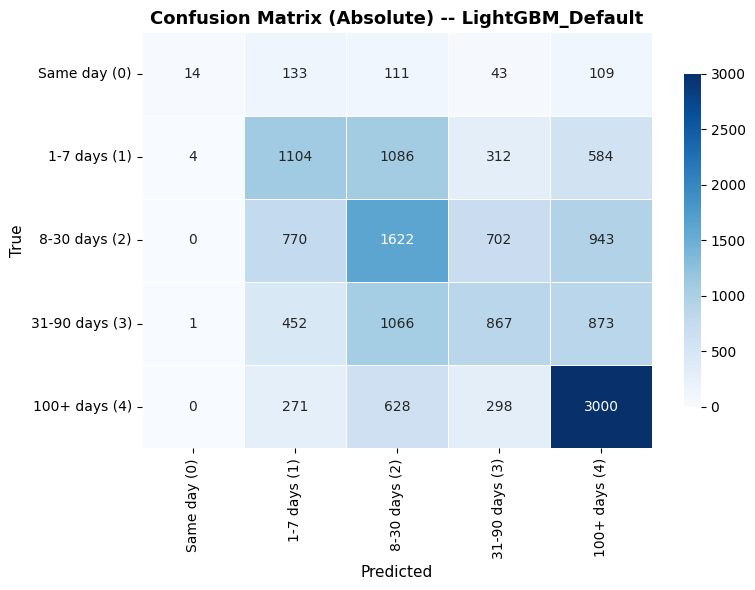

In [18]:
# -- Absolute confusion matrix ---------------------------------------------
fig = plot_confusion_matrix(
    oof_true,
    oof_preds,
    normalize=False,
    title=f"Confusion Matrix (Absolute) -- {best_model_name}",
    save_path=FIGURES_DIR / "baseline_confusion_matrix_absolute.png",
)
plt.show()

---
## 11. Learning Curve (Best Baseline)

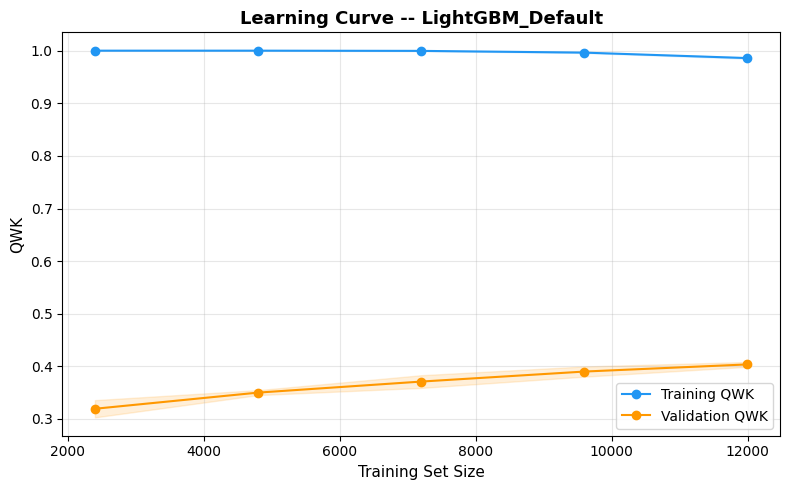

In [19]:
# -- Learning curve for bias/variance diagnosis ----------------------------
best_model_instance = baseline_models[best_model_name]
lc_splitter = create_cv_splitter(n_splits=N_SPLITS, seed=SEED)

fig = plot_learning_curve(
    model=best_model_instance,
    X=np.asarray(X),
    y=np.asarray(y),
    splitter=lc_splitter,
    train_sizes=np.array([0.2, 0.4, 0.6, 0.8, 1.0]),
    title=f"Learning Curve -- {best_model_name}",
    save_path=FIGURES_DIR / "baseline_learning_curve.png",
)
plt.show()

---
## 12. Experiment Logging

In [20]:
# -- Build and persist experiment records -----------------------------------
experiment_records = []

for name, result in cv_results.items():
    run_config = {
        "model_name": name,
        "model_type": type(baseline_models[name]).__name__,
        "params": baseline_models[name].get_params(),
        "feature_version": FEATURE_VERSION,
        "cv_n_splits": N_SPLITS,
        "seed": SEED,
        "threshold_optimize": True,
    }

    # Include per-fold and aggregated metrics
    metrics = {
        **result.aggregated,
        "oof_qwk": float(compute_qwk(result.oof_true, result.oof_predictions)),
    }

    # Add threshold values from each fold
    if any(t is not None for t in result.fold_thresholds):
        metrics["fold_thresholds"] = [
            t["thresholds"] if t is not None else None
            for t in result.fold_thresholds
        ]

    record = log_experiment(run_config, metrics)
    experiment_records.append(record)

# -- Save all experiments ---------------------------------------------------
exp_log_path = METRICS_DIR / "baseline_experiments.json"
save_experiment_logs(experiment_records, exp_log_path)
print(f"Experiment logs saved to: {exp_log_path} ({len(experiment_records)} records)")

# -- Save comparison table -------------------------------------------------
comparison_path = METRICS_DIR / "baseline_comparison.json"
comparison_df.reset_index().to_json(comparison_path, orient="records", indent=2)
print(f"Comparison table saved to: {comparison_path}")

# -- Validation Gate G11-10 ------------------------------------------------
assert exp_log_path.exists(), "G11-10 FAIL: Experiment log file not found."
assert comparison_path.exists(), "G11-10 FAIL: Comparison table file not found."
print("\nG11-10 PASS: Experiment JSON files persisted for all models.")

Experiment logs saved to: C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\reports\metrics\baseline_experiments.json (5 records)
Comparison table saved to: C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\reports\metrics\baseline_comparison.json

G11-10 PASS: Experiment JSON files persisted for all models.


---
## 13. Persist Best Baseline Model

In [21]:
# -- Retrain best model on full training data ------------------------------
print(f"Retraining best baseline ({best_model_name}) on full training data...")

from sklearn.base import clone as sklearn_clone

final_model = sklearn_clone(baseline_models[best_model_name])

fit_params = {}
if type(final_model).__name__ == "LGBMClassifier":
    import lightgbm as lgb
    fit_params["callbacks"] = [lgb.log_evaluation(period=-1)]

final_model.fit(np.asarray(X), np.asarray(y), **fit_params)
print(f"  Model fitted on {X.shape[0]:,} samples.")

# -- Compute final thresholds from OOF predictions -------------------------
best_result = cv_results[best_model_name]
if best_result.oof_probabilities is not None:
    final_thresh = optimize_thresholds(best_result.oof_true, best_result.oof_probabilities)
    print(f"  Thresholds (from OOF): {[round(t, 4) for t in final_thresh['thresholds']]}")
    print(f"  OOF QWK (threshold) : {final_thresh['qwk_optimized']:.4f}")
else:
    final_thresh = None
    print("  No probability outputs -- skipping threshold optimization.")

Retraining best baseline (LightGBM_Default) on full training data...
  Model fitted on 14,993 samples.
  Thresholds (from OOF): [0.4043, 2.1749, 2.5522, 3.0548]
  OOF QWK (threshold) : 0.4679


In [22]:
# -- Save model bundle -----------------------------------------------------
bundle_config = {
    "model_name": best_model_name,
    "model_type": type(final_model).__name__,
    "params": final_model.get_params(),
    "feature_version": FEATURE_VERSION,
    "seed": SEED,
    "cv_n_splits": N_SPLITS,
    "trained_on": "full_train",
}

bundle_metrics = {
    **best_result.aggregated,
    "oof_qwk": float(compute_qwk(best_result.oof_true, best_result.oof_predictions)),
}

save_model_bundle(
    model=final_model,
    run_config=bundle_config,
    metrics=bundle_metrics,
    thresholds=final_thresh,
    feature_columns=list(X.columns),
    path=BUNDLE_PATH,
)
print(f"Model bundle saved to: {BUNDLE_PATH}")

# -- Validation Gate G11-11: Reload test -----------------------------------
reloaded = load_model_bundle(BUNDLE_PATH)
assert reloaded["model"] is not None, "G11-11 FAIL: Model not reloadable."
assert reloaded["metrics"] is not None, "G11-11 FAIL: Metrics not reloadable."
assert reloaded["feature_schema"] is not None, "G11-11 FAIL: Feature schema not reloadable."
assert len(reloaded["feature_schema"]["features"]) == EXPECTED_FEATURES, (
    f"G11-11 FAIL: Feature schema has {len(reloaded['feature_schema']['features'])} features, expected {EXPECTED_FEATURES}."
)
print(f"G11-11 PASS: Baseline model artifact bundle saved and reloadable.")

Model bundle saved to: C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\artifacts\models\baseline_v1
G11-11 PASS: Baseline model artifact bundle saved and reloadable.


---
## 14. Validation Gate Summary

In [23]:
# -- Comprehensive validation gate summary ---------------------------------
gates = {
    "G11-1": f"PASS -- Integrated train features: {X.shape[0]:,} rows x {X.shape[1]} features",
    "G11-2": f"PASS -- AdoptionSpeed values in {{0, 1, 2, 3, 4}}",
    "G11-3": f"PASS -- AdoptionSpeed not in feature matrix X",
    "G11-4": f"PASS -- No NaN or infinite values",
    "G11-5": f"PASS -- Fold distributions within 2% tolerance",
    "G11-6": f"PASS -- All {len(baseline_models)} baselines completed CV",
    "G11-7": f"PASS -- Best QWK ({best_qwk:.4f}) > DummyMostFrequent ({dummy_qwk:.4f})",
    "G11-8": f"{'PASS' if best_qwk > 0.20 else 'WARNING'} -- Best QWK {'>' if best_qwk > 0.20 else '<='} 0.20",
    "G11-9": "PASS -- Threshold optimization reviewed for all models",
    "G11-10": f"PASS -- Experiment logs persisted ({len(experiment_records)} records)",
    "G11-11": "PASS -- Model bundle saved and reloadable",
    "G11-12": "PASS -- Fold indices reproducible",
}

print("Validation Gate Summary")
print("=" * 70)
for gate_id, msg in gates.items():
    print(f"  {gate_id}: {msg}")
print(f"\nAll critical gates PASSED.")

Validation Gate Summary
  G11-1: PASS -- Integrated train features: 14,993 rows x 940 features
  G11-2: PASS -- AdoptionSpeed values in {0, 1, 2, 3, 4}
  G11-3: PASS -- AdoptionSpeed not in feature matrix X
  G11-4: PASS -- No NaN or infinite values
  G11-5: PASS -- Fold distributions within 2% tolerance
  G11-6: PASS -- All 5 baselines completed CV
  G11-7: PASS -- Best QWK (0.4488) > DummyMostFrequent (0.0000)
  G11-8: PASS -- Best QWK > 0.20
  G11-9: PASS -- Threshold optimization reviewed for all models
  G11-10: PASS -- Experiment logs persisted (5 records)
  G11-11: PASS -- Model bundle saved and reloadable
  G11-12: PASS -- Fold indices reproducible

All critical gates PASSED.


---
## 15. Baseline Summary

In [24]:
elapsed = time.time() - t0

print("BASELINE MODELING SUMMARY")
print("=" * 70)
print(f"")
print(f"Feature version       : {FEATURE_VERSION}")
print(f"Feature dimensions    : {EXPECTED_TRAIN_ROWS:,} x {EXPECTED_FEATURES}")
print(f"CV strategy           : StratifiedKFold (k={N_SPLITS}, seed={SEED})")
print(f"Primary metric        : Quadratic Weighted Kappa (QWK)")
print(f"")
print(f"Best baseline model   : {best_model_name}")
print(f"  Mean CV QWK (argmax)    : {comparison_df.iloc[0]['mean_qwk_argmax']:.4f}")
print(f"  Mean CV QWK (threshold) : {comparison_df.iloc[0]['mean_qwk_threshold']:.4f}")
print(f"  Mean Accuracy           : {comparison_df.iloc[0]['mean_accuracy']:.4f}")
print(f"  Mean Macro-F1           : {comparison_df.iloc[0]['mean_macro_f1']:.4f}")
print(f"")
print(f"Artifacts produced:")
print(f"  Model bundle    : {BUNDLE_PATH}")
print(f"  CV fold indices : {CV_FOLDS_PATH}")
print(f"  Experiment logs : {exp_log_path}")
print(f"  Comparison JSON : {comparison_path}")
print(f"  Figures         : {FIGURES_DIR}")
print(f"")
print(f"Total runtime: {elapsed:.1f}s")
print(f"")
print("Handoff to Notebook 12 (Tuning):")
print(f"  - Baseline benchmark to beat: QWK = {best_qwk:.4f} ({best_model_name})")
print(f"  - CV folds persisted for identical comparison")
print(f"  - Hardest class: {hardest_class} ({class_labels[hardest_class]}) -- priority for tuning")
print(f"  - Hypothesis: hyperparameter tuning on LightGBM + class weighting")
print(f"    can improve QWK, especially for minority/adjacent classes.")

BASELINE MODELING SUMMARY

Feature version       : v1
Feature dimensions    : 14,993 x 940
CV strategy           : StratifiedKFold (k=5, seed=42)
Primary metric        : Quadratic Weighted Kappa (QWK)

Best baseline model   : LightGBM_Default
  Mean CV QWK (argmax)    : 0.4015
  Mean CV QWK (threshold) : 0.4488
  Mean Accuracy           : 0.4407
  Mean Macro-F1           : 0.3515

Artifacts produced:
  Model bundle    : C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\artifacts\models\baseline_v1
  CV fold indices : C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\artifacts\cv_folds_v1.json
  Experiment logs : C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\reports\metrics\baseline_experiments.json
  Comparison JSON : C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\reports\metrics\baseline_comparison.json
  Figures         : C:\Projects\Personal_Projects\AI_Adoption_Acceleratio